# Project Stage 2 - 2026

## 1. Import Libraries

In [1]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

## 2. Multi-Agent Environment Setup

### 2.1 Environment Description
The environment is designed to simulate a multi-agent coordination task on a remote planet, strictly aligning with the Stage 2 specifications. Two distinct agents (Type A and Type B) operate simultaneously within a 5x5 grid. 
* **Agent A** starts at the West landing site `X (2, 0)` and must retrieve a sample from the East target site `U (2, 4)`.
* **Agent B** starts at the North landing site `Y (0, 2)` and must retrieve a sample from the South target site `V (4, 2)`.
A dynamic ephemeral lake is located precisely at the intersection of their shortest paths `(2, 2)`, presenting significant environmental hazards.

### 2.2 State & Action Space
To enforce true decentralized learning, the environment implements partial observability. 
* **State Space:** Each agent can only observe its own coordinate, its sample-carrying status, and the current binary state of the lake (flooded/dry). Agents are strictly "blind" to each other's coordinates.
* **Action Space:** Both agents share a 5-action space: Up `(-1, 0)`, Down `(1, 0)`, Left `(0, -1)`, Right `(0, 1)`, and Wait `(0, 0)`.

### 2.3 The Step Function (Modular Architecture)
To handle the complex interplay of delays, task completion, and concurrent movements, the `step` function is refactored into a highly modular pipeline consisting of 6 distinct phases:

* **Module 1: Action Interception (Continuous Stream Simulation)**
  To simulate a continuous stream of robots without state-space explosion, agents are assigned random initial delays (0 to 4 steps). If an agent is still within its delay period, or has already completed its entire task, the environment forcefully overrides its chosen action to `Wait (4)`. This defensive programming prevents "ghost movements" and isolates learning logic.
* **Module 2: Movement Calculation & Wall Boundary**
  The environment calculates the intended next position for both agents simultaneously. If an action results in moving outside the 5x5 grid boundary, the action is invalidated, and the agent remains in its current position.
* **Module 3: Base Penalty Settlement & Start Position Lock**
  Standard energy costs are applied: `-5` for a regular step and `-3` for waiting. However, if an agent is in the "intercepted" state (delayed or already finished), it is granted a penalty-free status (Reward = 0) and its coordinates are firmly locked to its start position to prevent interference with the active agent.
* **Module 4: Task Progress (Sample Collection & Delivery)**
  The environment tracks the task lifecycle. Intermediate dense rewards (`+10`) are granted upon successfully picking up the sample at the target site. A terminal reward (`+50`) is awarded when the agent successfully returns to its start position with the sample, triggering the `finished` boolean flag.
* **Module 5: Environmental Hazards (Collision & Lake Penalties)**
  This module computes negative reinforcement for coordination failures.
    * **Collision Check:** If both active agents occupy the exact same coordinate simultaneously, both receive a massive `-20` penalty. Finished agents are exempt from this check.
    * **Phase-Specific Lake Penalty:** In Phase 1, Agent A lacks waterproofing. If Agent A steps into the lake while it is flooded, it incurs a `-20` penalty. In Phase 2, this penalty is removed to test multi-stability equilibrium.
* **Module 6: Lake Dynamics & Termination Check**
  Before concluding the step, the lake's state has a 20% probability of toggling between dry and flooded. The entire episode (`done = True`) strictly terminates only when both Agent A and Agent B have their `finished` flags set to True.

In [2]:
class MultiAgentEnv:
    def __init__(self, phase):
        self.phase = phase
        self.grid_size = 5
        self.lake_pos = (2, 2)
        
        # Key landmark coordinates (row, col)
        self.start_A = (2, 0)  # X
        self.start_B = (0, 2)  # Y
        self.target_A = (2, 4) # U
        self.target_B = (4, 2) # V
        
        # Action space: 0:Up, 1:Down, 2:Left, 3:Right, 4:Wait
        self.action_space = [(-1, 0), (1, 0), (0, -1), (0, 1), (0, 0)]
        self.p_lake_change = 0.2  # 20% probability of lake state changing per step
        
    def reset(self):
        self.pos_A = self.start_A
        self.pos_B = self.start_B
        self.A_has_sample = False
        self.B_has_sample = False
        self.A_finished = False
        self.B_finished = False
        self.lake_flooded = random.choice([True, False])
        self.A_delay = random.randint(0, 4)    # Random departure delay to simulate continuous stream
        self.B_delay = random.randint(0, 4)
        self.collision_count = 0               # Counter for collisions
        self.time = 0                          # Timer to record steps passed

        return self._get_states()

    def _get_states(self):
        """Returns the state observed by each agent"""
        state_A = (self.pos_A, self.A_has_sample, self.lake_flooded)
        state_B = (self.pos_B, self.B_has_sample, self.lake_flooded)
        return state_A, state_B

    def step(self, action_idx_A, action_idx_B):
            """Simultaneously executes actions for both agents"""
            self.time += 1
            # ==========================================
            # 1. Action Interception: Force wait if delayed or finished
            # ==========================================
            if self.time < self.A_delay or self.A_finished:
                action_idx_A = 4
            if self.time < self.B_delay or self.B_finished:
                action_idx_B = 4

            # ==========================================
            # 2. Movement Calculation & Wall Collision Check
            # ==========================================
            move_A = self.action_space[action_idx_A]
            move_B = self.action_space[action_idx_B]
            
            next_pos_A = (self.pos_A[0] + move_A[0], self.pos_A[1] + move_A[1])
            next_pos_B = (self.pos_B[0] + move_B[0], self.pos_B[1] + move_B[1])
            
            # Prevent moving out of bounds
            if not (0 <= next_pos_A[0] <= 4 and 0 <= next_pos_A[1] <= 4):
                next_pos_A = self.pos_A  
            if not (0 <= next_pos_B[0] <= 4 and 0 <= next_pos_B[1] <= 4):
                next_pos_B = self.pos_B
                
            self.pos_A = next_pos_A
            self.pos_B = next_pos_B

            # ==========================================
            # 3. Base reward Settlement 
            # ==========================================
            # Agent A 
            if self.time < self.A_delay or self.A_finished:
                reward_A = 0               
                self.pos_A = self.start_A  
            else:
                reward_A = -3 if action_idx_A == 4 else -5

            # Agent B 
            if self.time < self.B_delay or self.B_finished:
                reward_B = 0               
                self.pos_B = self.start_B  
            else:
                reward_B = -3 if action_idx_B == 4 else -5

            # ==========================================
            # 4. Task rewards for picking/delivering samples and status updates
            # ==========================================
            # Agent A 
            if self.pos_A == self.target_A and not self.A_has_sample:
                self.A_has_sample = True
                reward_A += 10
                
            if self.pos_A == self.start_A and self.A_has_sample and not self.A_finished:
                reward_A += 50
                self.A_finished = True
            
            # Agent B
            if self.pos_B == self.target_B and not self.B_has_sample:
                self.B_has_sample = True
                reward_B += 10
                
            if self.pos_B == self.start_B and self.B_has_sample and not self.B_finished:
                reward_B += 50
                self.B_finished = True

            # ==========================================
            # 5. Environmental Hazards
            # ==========================================
            if self.pos_A == self.pos_B and not self.A_finished and not self.B_finished:
                reward_A -= 20
                reward_B -= 20
                self.collision_count += 1 
                
            if self.lake_flooded and self.pos_A == self.lake_pos and self.phase == 1:
                reward_A -= 20
                
            # ==========================================
            # 6. Lake State Update & Termination Check
            # ==========================================
            if random.random() < self.p_lake_change:
                self.lake_flooded = not self.lake_flooded
                
            # Episode is done only when both agents finish
            done = (self.A_finished and self.B_finished)
            
            return self._get_states(), reward_A, reward_B, done


## 3. Q-Learning Algorithm with Expected Value Update

### 3.1 The Stochastic Environment Challenge
In Stage 1, the environment was deterministic. However, in Stage 2, the ephemeral lake introduces a stochastic element: at each time step, the lake has a probability $p$ (where $p = 0.2$) of changing its state (dry to flooded, or vice versa). 

If we use the standard Q-learning Bellman equation, which relies entirely on the sampled `next_state` provided by the environment, the TD Target will suffer from high variance. The agent's learning process will oscillate drastically because the same action in the same state might lead to completely different future rewards (e.g., crossing safely vs. water damage penalty) simply due to the random environment transition.

### 3.2 The Expected Bellman Update (Sarah's Approach)
To overcome this instability and solve the coordination task, we upgrade the standard Q-learning update to explicitly calculate the **Expected Value** of the future state.

The standard Q-learning update rule is defined as:
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a') - Q(S_t, A_t) \right]$$

To account for the lake's stochasticity, we split $S_{t+1}$ into two parallel state realities:
1. $S_{t+1}^{same}$: The lake state remains unchanged (Probability: $1 - p$).
2. $S_{t+1}^{changed}$: The lake state flips (Probability: $p$).

Instead of relying on the random outcome, we compute the expected maximum future Q-value:
$$\mathbb{E}[\max_{a'} Q(S_{t+1}, a')] = (1 - p) \cdot \max_{a'} Q(S_{t+1}^{same}, a') + p \cdot \max_{a'} Q(S_{t+1}^{changed}, a')$$

We then substitute this expected value directly into the Q-learning update rule:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \cdot \mathbb{E}[\max_{a'} Q(S_{t+1}, a')] - Q(S_t, A_t) \right]$$

### 3.3 Code Implementation Mapping
Our custom `learn` function directly translates this robust mathematical theory into code:
* `max_q_same` perfectly corresponds to $\max_{a'} Q(S_{t+1}^{same}, a')$.
* `max_q_changed` corresponds to $\max_{a'} Q(S_{t+1}^{changed}, a')$.
* `expected_max_next_q` computes the exact expectation $\mathbb{E}$.
This probabilistic approach completely neutralizes the environmental variance, allowing the agents to converge safely and optimally.

In [3]:
class QLearningAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.99, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.9995):
        self.actions = actions
        self.alpha = alpha       
        self.gamma = gamma       
        self.epsilon = epsilon   
        self.epsilon_min = epsilon_min       
        self.epsilon_decay = epsilon_decay   
        self.q_table = defaultdict(lambda: [0.0] * len(actions))

    def choose_action(self, state):
        """Selects an action based on the epsilon-greedy policy."""
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = self.q_table[state]
            max_q = max(q_values)
            # Randomly select an action if multiple actions share the maximum Q-value
            max_action = [action for action, q in enumerate(q_values) if q == max_q]   
            return random.choice(max_action)

    def learn(self, state, action, reward, next_state, done, p_change=0.2):
            """
            Executes a Q-learning update based on mathematical expectation.
            Handles episode termination logic and adapts to environmental stochasticity
            by calculating the expected maximum Q-value across two potential lake states (Sarah's approach).
            """
            if done:
                td_target = reward
            else:
                # 1. Unpack next_state
                next_pos, has_sample, _ = next_state
                
                # 2. Retrieve the lake state at the beginning of the step
                current_lake = state[2]
                
                # 3. Scenario A (80% probability): Lake state remains unchanged
                state_same = (next_pos, has_sample, current_lake)
                max_q_same = max(self.q_table[state_same])
                
                # 4. Scenario B (20% probability): Lake state flips
                state_changed = (next_pos, has_sample, not current_lake)
                max_q_changed = max(self.q_table[state_changed])
                
                # 5. Calculate the mathematical expectation of the future maximum Q-value
                expected_max_next_q = (1 - p_change) * max_q_same + p_change * max_q_changed
                
                # 6. Calculate the final TD Target
                td_target = reward + self.gamma * expected_max_next_q
                
            # Calculate the TD error and update the Q-value
            td_error = td_target - self.q_table[state][action]
            self.q_table[state][action] += self.alpha * td_error

    def decay_epsilon(self):
        """Decays the exploration rate (epsilon) at the end of each episode."""
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

## 4. Multi-Agent Training & Experimental Methodology

### 4.1 Decentralized Learning and Partial Observability
The core challenge of this multi-agent setup is that the agents are completely blind to each other's coordinates. This is a strict decentralized learning environment governed by partial observability. An agent only knows its own position, its sample status, and the lake's flooded/dry condition. 

They learn to avoid collisions not by physically "seeing" each other, but by receiving a massive shared negative reward (-20) when they accidentally crash in the lake. This severe environmental feedback forces them to eventually learn to use the lake's stochastic state (flooded vs. dry) as a shared "traffic light," achieving perfect coordination without ever relying on direct communication.

### 4.2 Multi-Seed Evaluation for Algorithmic Stability
Reinforcement learning in a multi-agent setting often suffers from high variance. A "lucky" initial exploration phase might lead to quick convergence, while an "unlucky" one might trap the agents in suboptimal loops. 

To scientifically validate our Expected Value Q-learning approach, the training loop was executed across 5 independent random seeds for 20,000 episodes. By calculating the statistical Mean and plotting the Standard Deviation as error bars, we can differentiate between a fluke and genuine algorithmic stability. The persistent 1% exploration rate (epsilon = 0.01) ensures the agents continuously test their environment, preventing them from collapsing into local optima.

### 4.3 Empirical Insights from the Learning Curves
The generated dashboard (Averaged over 5 Seeds) provides definitive proof that the Q-learning algorithm successfully solves the coordination tasks. Across both phases, we observe a dramatic and rapid improvement: the average reward climbs steeply from roughly -600 to positive territory, while the collision count plummets from over 5 per episode to near zero within the first 2500 episodes. Beyond this general success, the charts reveal profound structural differences between the two phases:

* **Phase 1 (The Asymmetric Coordination Game):** In the top-left reward chart, Agent A's reward curve (orange) is visibly slightly lower than Agent B's (blue) during the early episodes. This flawlessly reflects the asymmetry: Agent A suffers a severe penalty for entering flooded water, acting as a natural symmetry-breaker. Because of this clear environmental "hint", the collision rate (bottom-left) drops rapidly, and the error bars shrink significantly. The agents quickly agree on a unique stable equilibrium: Agent A crosses when dry, and Agent B crosses when flooded.

* **Phase 2 (The Symmetric Anti-Coordination Game):** Once the water penalty is removed, the environment becomes perfectly symmetric. This is immediately visible in the top-right chart, where Agent A and Agent B's reward curves overlap almost perfectly. However, the collision chart (bottom-right) reveals the hidden cost of symmetry: the error bars (Standard Deviation) are noticeably larger throughout the training. Without the environmental hint to break the tie, the identical agents engage in a tug-of-war to establish dominance. The larger variance proves that independent Q-learners struggle more with equilibrium selection in symmetric games (Multistability), though the long, stable plateau ultimately confirms they reach a Nash equilibrium over extended training.

In [4]:
def train_agents(env, agent_A, agent_B, episodes=20000, max_steps=100): 
    """
    Multi-Agent Q-Learning Training Loop.
    """
    # Initialize metric trackers for evaluation
    rewards_A = []
    rewards_B = []
    collision_history = []  

    # -----------------------------------------
    # Main Training Loop: Iterating through each episode
    # -----------------------------------------
    for episode in range(episodes):
        state_A, state_B = env.reset()  
        total_reward_A, total_reward_B = 0, 0
        step_count = 0 
        
        while True:
            # 1. Action Selection (Epsilon-greedy policy)
            action_A = agent_A.choose_action(state_A)     
            action_B = agent_B.choose_action(state_B)
            # 2. Execute actions and observe next states and rewards
            next_states, reward_A, reward_B, done = env.step(action_A, action_B)  

            # 3. Q-Value Update
            if reward_A != 0:
                agent_A.learn(state_A, action_A, reward_A, next_states[0], done)
                
            if reward_B != 0:
                agent_B.learn(state_B, action_B, reward_B, next_states[1], done)
            
            # 4. State Transition, Metric Accumulation
            total_reward_A += reward_A
            total_reward_B += reward_B
            state_A, state_B = next_states    
            step_count += 1 

            # 5. Check for episode termination
            if done or step_count >= max_steps:
                break
        
        # --- Episode Conclusion ---
        rewards_A.append(total_reward_A)
        rewards_B.append(total_reward_B)
        collision_history.append(env.collision_count)  

        # Decay exploration rate for both agents
        agent_A.decay_epsilon()
        agent_B.decay_epsilon()
        
    return rewards_A, rewards_B, collision_history

def train_multiple_seeds(phase, n_seeds=5, episodes=20000, verbose=True):
    """Train with multiple random seeds, returning reward and collision history data."""
    all_rewards_A = []
    all_rewards_B = []
    all_collisions = []
    final_agents = []  
    
    for seed in range(n_seeds):
        # 1. Fix random seed for reproducibility
        random.seed(seed)
        
        # 2. Initialize environment and agents
        env = MultiAgentEnv(phase=phase)
        agent_A = QLearningAgent(actions=range(5), alpha=0.1, gamma=0.99, epsilon=1.0)
        agent_B = QLearningAgent(actions=range(5), alpha=0.1, gamma=0.99, epsilon=1.0)
        
        # 3. Execute training episodes
        rewards_A, rewards_B, collisions = train_agents(env, agent_A, agent_B, episodes=episodes)
        
        # 4. Collect and record training results
        all_rewards_A.append(rewards_A)
        all_rewards_B.append(rewards_B)
        all_collisions.append(collisions)
        final_agents.append((agent_A, agent_B))
        
        if verbose:
           print(f" Phase {phase} - Seed {seed+1}/{n_seeds} training completed")

    return {'rewards_A': all_rewards_A,'rewards_B': all_rewards_B,'collisions': all_collisions,'agents': final_agents}

# Perform multi-seed training for Phase 1 and Phase 2 respectively
print(" Training Phase 1 with 5 seeds...")
results_p1 = train_multiple_seeds(phase=1, n_seeds=5)
print("\n Training Phase 2 with 5 seeds...")
results_p2 = train_multiple_seeds(phase=2, n_seeds=5)

 Training Phase 1 with 5 seeds...
 Phase 1 - Seed 1/5 training completed
 Phase 1 - Seed 2/5 training completed
 Phase 1 - Seed 3/5 training completed
 Phase 1 - Seed 4/5 training completed
 Phase 1 - Seed 5/5 training completed

 Training Phase 2 with 5 seeds...
 Phase 2 - Seed 1/5 training completed
 Phase 2 - Seed 2/5 training completed
 Phase 2 - Seed 3/5 training completed
 Phase 2 - Seed 4/5 training completed
 Phase 2 - Seed 5/5 training completed


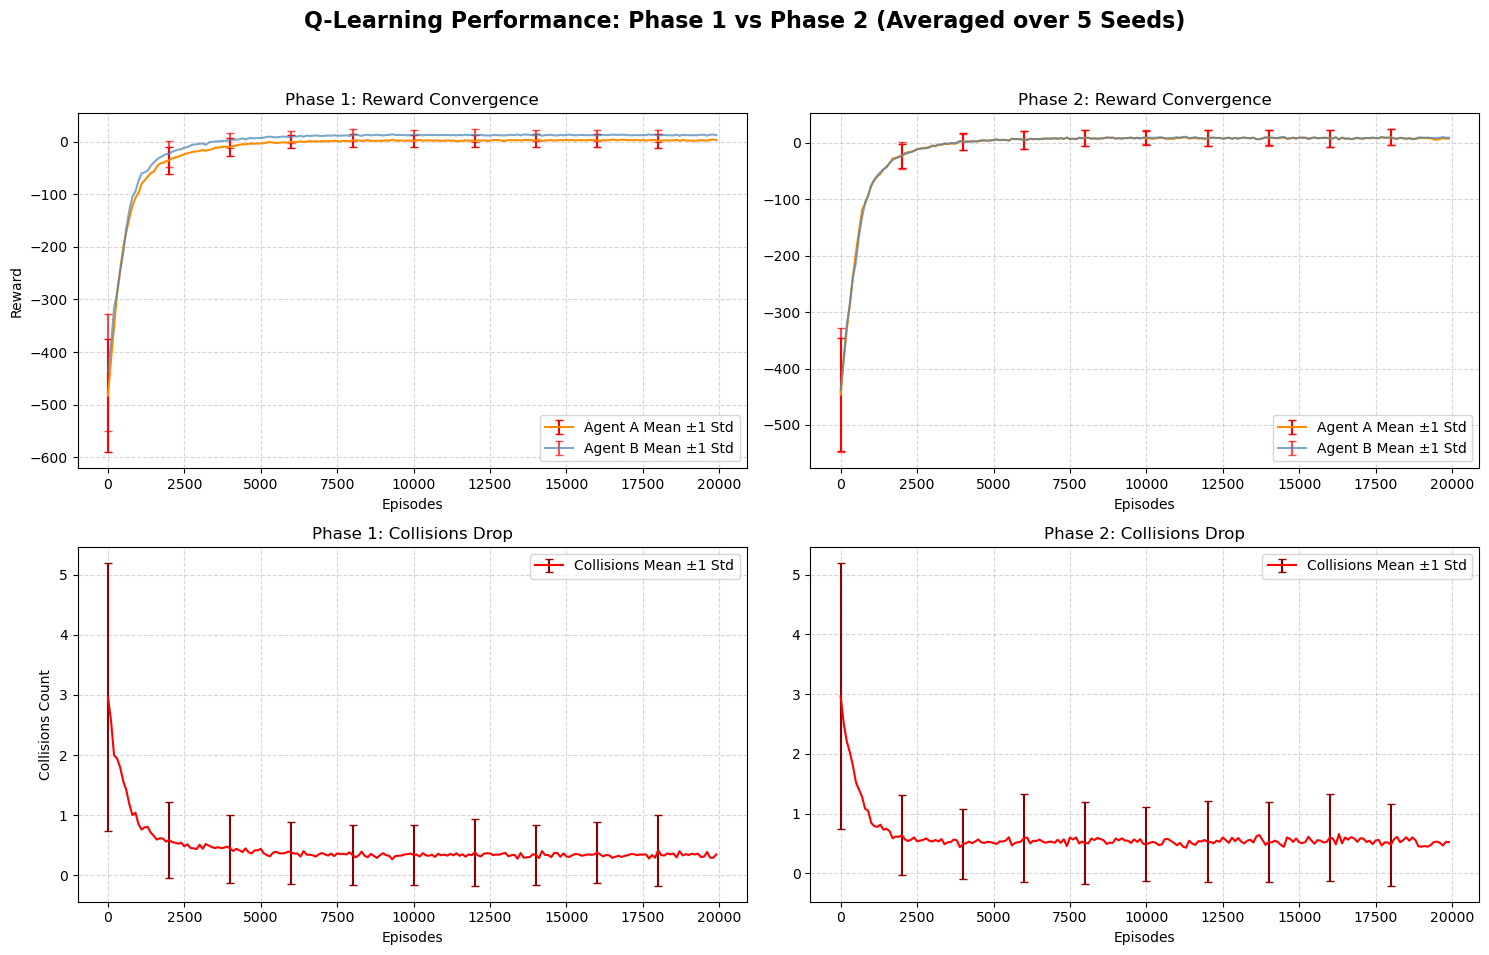

In [5]:
def plot_dashboard(results_p1, results_p2, window_size=100):
    """
    Plot the training results dashboard.
    Use mean and standard deviation to show statistical performance across multiple seeds.
    """
    # 1. Convert list data to NumPy arrays for matrix computation (5 rows x 20000 columns)
    rewards_A_p1_matrix = np.array(results_p1['rewards_A'])     # phase 1
    rewards_B_p1_matrix = np.array(results_p1['rewards_B'])
    collisions_p1_matrix = np.array(results_p1['collisions'])
    
    rewards_A_p2_matrix = np.array(results_p2['rewards_A'])     # phase 2
    rewards_B_p2_matrix = np.array(results_p2['rewards_B'])
    collisions_p2_matrix = np.array(results_p2['collisions'])

    # 2. Calculate the mean and standard deviation (Std) for the 5 agents per episode
    mean_rew_A_p1 = np.mean(rewards_A_p1_matrix, axis=0)
    std_rew_A_p1 = np.std(rewards_A_p1_matrix, axis=0)
    
    mean_rew_B_p1 = np.mean(rewards_B_p1_matrix, axis=0)
    std_rew_B_p1 = np.std(rewards_B_p1_matrix, axis=0)
    
    mean_colli_p1 = np.mean(collisions_p1_matrix, axis=0)
    std_colli_p1 = np.std(collisions_p1_matrix, axis=0)

    # Phase 2
    mean_rew_A_p2 = np.mean(rewards_A_p2_matrix, axis=0)
    std_rew_A_p2 = np.std(rewards_A_p2_matrix, axis=0)
    
    mean_rew_B_p2 = np.mean(rewards_B_p2_matrix, axis=0)
    std_rew_B_p2 = np.std(rewards_B_p2_matrix, axis=0)
    
    mean_colli_p2 = np.mean(collisions_p2_matrix, axis=0)
    std_colli_p2 = np.std(collisions_p2_matrix, axis=0)

    # 3. Apply moving average to smooth data
    def smooth_data(data):
        return [np.mean(data[i:i+window_size]) for i in range(0, len(data), window_size)]

    # Smooth Phase 1 data
    sm_mean_A_p1 = smooth_data(mean_rew_A_p1)
    sm_std_A_p1 = smooth_data(std_rew_A_p1)
    sm_mean_B_p1 = smooth_data(mean_rew_B_p1)
    sm_std_B_p1 = smooth_data(std_rew_B_p1)
    sm_mean_col_p1 = smooth_data(mean_colli_p1)
    sm_std_col_p1 = smooth_data(std_colli_p1)
    
    # Smooth Phase 2 data
    sm_mean_A_p2 = smooth_data(mean_rew_A_p2)
    sm_std_A_p2 = smooth_data(std_rew_A_p2)
    sm_mean_B_p2 = smooth_data(mean_rew_B_p2)
    sm_std_B_p2 = smooth_data(std_rew_B_p2)
    sm_mean_col_p2 = smooth_data(mean_colli_p2)
    sm_std_col_p2 = smooth_data(std_colli_p2)

    # 4. Generate X-axis coordinates
    episodes_x = range(0, len(mean_rew_A_p1), window_size)

    # ==================== Start plotting (2x2 canvas) ====================
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("Q-Learning Performance: Phase 1 vs Phase 2 (Averaged over 5 Seeds)", fontsize=16, fontweight='bold')

    # ---------- Top-left: Phase 1 Rewards ----------
    axs[0, 0].errorbar(episodes_x, sm_mean_A_p1, yerr=sm_std_A_p1, color='darkorange', ecolor='red', capsize=3, errorevery=20, label='Agent A Mean ±1 Std')
    axs[0, 0].errorbar(episodes_x, sm_mean_B_p1, yerr=sm_std_B_p1, color='steelblue', ecolor='red', capsize=3, errorevery=20, label='Agent B Mean ±1 Std', alpha=0.7)
    axs[0, 0].set_title("Phase 1: Reward Convergence")
    axs[0, 0].set_xlabel("Episodes"); axs[0, 0].set_ylabel("Reward")
    axs[0, 0].grid(True, linestyle='--', alpha=0.5); axs[0, 0].legend()

    # ---------- Top-right: Phase 2 Rewards ----------
    axs[0, 1].errorbar(episodes_x, sm_mean_A_p2, yerr=sm_std_A_p2, color='darkorange', ecolor='red', capsize=3, errorevery=20, label='Agent A Mean ±1 Std')
    axs[0, 1].errorbar(episodes_x, sm_mean_B_p2, yerr=sm_std_B_p2, color='steelblue', ecolor='red', capsize=3, errorevery=20, label='Agent B Mean ±1 Std', alpha=0.7)
    axs[0, 1].set_title("Phase 2: Reward Convergence")
    axs[0, 1].set_xlabel("Episodes")
    axs[0, 1].grid(True, linestyle='--', alpha=0.5); axs[0, 1].legend()

    # ---------- Bottom-left: Phase 1 Collisions ----------
    axs[1, 0].errorbar(episodes_x, sm_mean_col_p1, yerr=sm_std_col_p1, color='red', ecolor='darkred', capsize=3, errorevery=20, label='Collisions Mean ±1 Std')
    axs[1, 0].set_title("Phase 1: Collisions Drop")
    axs[1, 0].set_xlabel("Episodes"); axs[1, 0].set_ylabel("Collisions Count")
    axs[1, 0].grid(True, linestyle='--', alpha=0.5); axs[1, 0].legend()

    # ---------- Bottom-right: Phase 2 Collisions ----------
    axs[1, 1].errorbar(episodes_x, sm_mean_col_p2, yerr=sm_std_col_p2, color='red', ecolor='darkred', capsize=3, errorevery=20, label='Collisions Mean ±1 Std')
    axs[1, 1].set_title("Phase 2: Collisions Drop")
    axs[1, 1].set_xlabel("Episodes")
    axs[1, 1].grid(True, linestyle='--', alpha=0.5); axs[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_dashboard(results_p1, results_p2)

### 5. Comprehensive Evaluation & Behavioral Analysis

#### 5.1 Evaluation Methodology
To rigorously assess the learned policies and prove algorithmic stability, we conducted a comprehensive evaluation that strictly isolates the exploitation phase from the training phase:
* **Pure Exploitation (Zero Exploration):** The exploration rate ($\epsilon$) for both agents was set to 0. This ensures the evaluation precisely measures the deterministic optimal policy derived from the converged Q-tables, rather than random exploratory actions.
* **Statistical Robustness:** The evaluation was executed across the 5 independently trained models (representing 5 random seeds). Each pair of agents was evaluated for 1,000 episodes in pristine, newly instantiated test environments to prevent state contamination.
* **Decision-State Logging:** To evaluate whether the agents successfully learned to use the lake as a conditional signal, the state of the lake (DRY or FLOODED) was recorded strictly at the precise moment an agent initiated a crossing step.

#### 5.2 Phase 1 Analysis: Asymmetric Coordination & Rational Collisions

| Evaluation Metrics (Phase 1) | Agent A (Vulnerable) | Agent B (Waterproof) |
| :--- | :--- | :--- |
| **Enters Lake when DRY** | 100.00% ± 0.00 | 49.43% ± 1.42 |
| **Enters Lake when FLOODED** | 0.00% ± 0.00 | 50.57% ± 1.42 |
| **Avg. Steps to Complete** | 10.21 ± 0.09 | 8.20 ± 0.03 |
| **Global Metrics** | **Collisions:** 0.312 ± 0.023 | **Success Rate:** 100.00% ± 0.00 |

**Behavioral Insights:**
* **Perfect Coordination via Symmetry Breaking:** Agent A exhibits a 100.00% probability of crossing when the lake is DRY, with a standard deviation of 0.00. This perfectly validates the theoretical hypothesis: the severe water penalty acts as a natural symmetry-breaker. Agent A treats the lake's state as a strict "traffic light", completely avoiding the flooded state.
* **Rational Collisions under Partial Observability:** Despite this high-level coordination, the average collision rate did not drop to an absolute zero (0.312). This is a rational consequence of **Partial Observability**. Because Agent B cannot observe Agent A's position, it faces a strict trade-off: incur a guaranteed continuous penalty for waiting (-3 per step) or risk a probabilistic collision penalty (-20). Over time, Agent B learns that the **mathematical expectation** of crossing blindly yields a higher overall return than conservatively waiting for an unseen agent. Therefore, its decision to cross regardless of the lake's state (an approximate 50/50 distribution) is actually an optimal rational choice based on expected value. The rare collisions occur only when both agents' randomized departure delays align perfectly at the lake during a DRY state.

#### 5.3 Phase 2 Analysis: Symmetric Anti-Coordination & Multistability

| Evaluation Metrics (Phase 2) | Agent A (Waterproof) | Agent B (Waterproof) |
| :--- | :--- | :--- |
| **Enters Lake when DRY** | 53.89% ± 7.22 | 50.84% ± 1.14 |
| **Enters Lake when FLOODED** | 46.11% ± 7.22 | 49.16% ± 1.14 |
| **Avg. Steps to Complete** | 8.36 ± 0.38 | 8.21 ± 0.05 |
| **Global Metrics** | **Collisions:** 0.522 ± 0.047 | **Success Rate:** 100.00% ± 0.00 |

**Behavioral Insights:**
* **Equilibrium Selection Failure:** Without the environmental hint (water penalty) to break the symmetry, the game regresses into a perfectly symmetric anti-coordination game. Both agents struggle to establish a mutually exclusive crossing rule, resulting in crossing probabilities that hover near 50% for both DRY and FLOODED states.
* **Multistability and High Variance:** The elevated standard deviation (e.g., ± 7.22 for Agent A) highlights the core weakness of independent Q-learners in symmetric games. Different random seeds converged to different local equilibria (path dependence). This proves that while the system possesses stable Nash equilibria theoretically, decentralized learning agents without direct communication or external symmetry-breaking mechanisms cannot reliably coordinate on a single joint strategy.

In [6]:
def evaluate_policy(env, agent_A, agent_B, n_episodes=1000):
    # 1. Disable exploration during evaluation
    # Setting epsilon to 0 enforces pure exploitation of the learned Q-values.
    agent_A.epsilon = 0
    agent_B.epsilon = 0
    
    # 2. Metrics initialization
    # Track the state of the lake (dry or flooded) strictly at the moment an agent decides to enter it.
    A_lake_visits = {'dry': 0, 'flooded': 0}
    B_lake_visits = {'dry': 0, 'flooded': 0}

    total_collisions = 0    
    total_steps_A = []       
    total_steps_B = []       
    success_count = 0        
    
    # 3. Execute evaluation loop over the specified number of episodes (default 1000)
    for _ in range(n_episodes):
        state_A, state_B = env.reset()  
        steps_A, steps_B = 0, 0      
        
        # Apply episode truncation (max 100 steps) to prevent infinite loops in non-converged policies.
        for step in range(100):
            # Select the optimal action based on current Q-table values
            action_A = agent_A.choose_action(state_A)
            action_B = agent_B.choose_action(state_B)
            
            # 4. Pre-step State Logging
            # Record the lake state prior to the environmental step. Since the lake state has a 20% probability of transitioning during the step
            # evaluating the agent's decision-making requires the exact observation it based its action upon.
            lake_before_step = env.lake_flooded  
            
            # Evaluate Agent A's crossing decision:
            # Calculate the intended next position using the current position and action offset. 
            # Flag as True if the intended destination is the lake and the task is incomplete.
            a_will_enter_lake = (
                env.action_space[action_A][0] + env.pos_A[0], env.action_space[action_A][1] + env.pos_A[1] 
                ) == env.lake_pos and not env.A_finished
            
            b_will_enter_lake = (
                env.action_space[action_B][0] + env.pos_B[0], env.action_space[action_B][1] + env.pos_B[1]
                ) == env.lake_pos and not env.B_finished
            
            # 5. Execute the selected actions in the environment
            next_states, r_A, r_B, done = env.step(action_A, action_B)
            
            # 6. Process evaluation metrics based on pre-step decisions
            # If an agent intended to enter the lake, log the crossing under the lake state observed prior to the step.
            if a_will_enter_lake:
                key = 'flooded' if lake_before_step else 'dry'
                A_lake_visits[key] += 1
            if b_will_enter_lake:
                key = 'flooded' if lake_before_step else 'dry'
                B_lake_visits[key] += 1
            
            # 7. Record valid step counts
            # Accumulate steps only while the respective agent's task remains incomplete.
            if not env.A_finished:
                steps_A += 1
            if not env.B_finished:
                steps_B += 1
            
            state_A, state_B = next_states
            
            # Check for episode termination
            if done:
                success_count += 1
                break
        
        # Append episode-level metrics to the aggregate tracking variables
        total_collisions += env.collision_count
        total_steps_A.append(steps_A)
        total_steps_B.append(steps_B)
    
    # 8. Return the 1000 episodes evaluation metrics
    return {
        'A_lake': A_lake_visits,                                # Total crossings by A in dry/flooded states
        'B_lake': B_lake_visits,                                # Total crossings by B in dry/flooded states
        'avg_collisions': total_collisions / n_episodes,        # Average collisions per episode
        'avg_steps_A': np.mean(total_steps_A),                  # Average steps to completion for Agent A
        'avg_steps_B': np.mean(total_steps_B),                  # Average steps to completion for Agent B
        'success_rate': success_count / n_episodes              # Overall success rate
    }


def comprehensive_evaluation(results, phase_name, n_episodes=1000):
    """
    Conducts a comprehensive evaluation across models trained on 5 distinct random seeds.
    Executes n_episodes per model pair and aggregates the results to report the 
    statistical mean and standard deviation, ensuring algorithmic robustness.
    """
    
    # 1. Initialize a dictionary to aggregate metrics across all evaluated seeds
    all_metrics = {
        'A_dry_pct': [], 'A_flooded_pct': [],    # Crossing percentages for A in respective states
        'B_dry_pct': [], 'B_flooded_pct': [],    # Crossing percentages for B in respective states
        'collisions': [], 'steps_A': [], 'steps_B': [], # Collision and step counters
        'success_rate': []                       # Success rate percentages
    }
    
    # 2. Determine the corresponding environment phase parameter
    phase_val = 1 if "1" in phase_name else 2
    
    # 3. Iterate through the agents trained across different seeds
    for seed_idx, (agent_A, agent_B) in enumerate(results['agents']):
        test_env = MultiAgentEnv(phase=phase_val)
        
        # Evaluate the current pair of agents over the specified number of episodes
        evaluation = evaluate_policy(test_env, agent_A, agent_B, n_episodes=n_episodes)
        
        # 4. Calculate total lake crossings for both agents to normalize the percentages
        # Sum the crossings in both dry and flooded states to determine the total number of intentional lake entries for Agents A and B.
        a_total = evaluation['A_lake']['dry'] + evaluation['A_lake']['flooded']
        b_total = evaluation['B_lake']['dry'] + evaluation['B_lake']['flooded']
        
        # 5. Process and append metrics: Convert raw crossing counts into percentages. 
        # Implements a ZeroDivisionError safeguard (if total > 0) in cases where the agent fully avoids the lake.
        all_metrics['A_dry_pct'].append(evaluation['A_lake']['dry'] / a_total * 100 if a_total > 0 else 0)
        all_metrics['A_flooded_pct'].append(evaluation['A_lake']['flooded'] / a_total * 100 if a_total > 0 else 0)
        all_metrics['B_dry_pct'].append(evaluation['B_lake']['dry'] / b_total * 100 if b_total > 0 else 0)
        all_metrics['B_flooded_pct'].append(evaluation['B_lake']['flooded'] / b_total * 100 if b_total > 0 else 0)
        
        # Append the remaining pre-calculated averages
        all_metrics['collisions'].append(evaluation['avg_collisions'])
        all_metrics['steps_A'].append(evaluation['avg_steps_A'])
        all_metrics['steps_B'].append(evaluation['avg_steps_B'])
        all_metrics['success_rate'].append(evaluation['success_rate'] * 100) # Scale to percentage format
    
    # 6. Output the formatted statistical summary 
    print(f"\n{'='*70}")
    print(f"  {phase_name} — Comprehensive Evaluation (5 seeds × {n_episodes} episodes)")
    print(f"{'='*70}")
    
    # Compute and display the statistical mean and standard deviation across all seeds to validate policy stability.
    # Outputs are formatted to 2 decimal places for optimal alignment.
    print(f"  Agent A enters lake when DRY:     {np.mean(all_metrics['A_dry_pct']):6.2f}% ± {np.std(all_metrics['A_dry_pct']):5.2f}")
    print(f"  Agent A enters lake when FLOODED: {np.mean(all_metrics['A_flooded_pct']):6.2f}% ± {np.std(all_metrics['A_flooded_pct']):5.2f}")
    print(f"  Agent B enters lake when DRY:     {np.mean(all_metrics['B_dry_pct']):6.2f}% ± {np.std(all_metrics['B_dry_pct']):5.2f}")
    print(f"  Agent B enters lake when FLOODED: {np.mean(all_metrics['B_flooded_pct']):6.2f}% ± {np.std(all_metrics['B_flooded_pct']):5.2f}")
    print(f"  Avg collisions per episode:       {np.mean(all_metrics['collisions']):6.3f} ± {np.std(all_metrics['collisions']):5.3f}")
    print(f"  Avg steps Agent A:                {np.mean(all_metrics['steps_A']):6.2f} ± {np.std(all_metrics['steps_A']):5.2f}")
    print(f"  Avg steps Agent B:                {np.mean(all_metrics['steps_B']):6.2f} ± {np.std(all_metrics['steps_B']):5.2f}")
    print(f"  Success rate:                     {np.mean(all_metrics['success_rate']):6.2f}% ± {np.std(all_metrics['success_rate']):5.2f}")
    
    return all_metrics

# Evaluation of the trained agents from Phase 1 and Phase 2, with comprehensive metrics reporting
metrics_p1 = comprehensive_evaluation(results_p1, "PHASE 1")
metrics_p2 = comprehensive_evaluation(results_p2, "PHASE 2")


  PHASE 1 — Comprehensive Evaluation (5 seeds × 1000 episodes)
  Agent A enters lake when DRY:     100.00% ±  0.00
  Agent A enters lake when FLOODED:   0.00% ±  0.00
  Agent B enters lake when DRY:      48.74% ±  1.50
  Agent B enters lake when FLOODED:  51.26% ±  1.50
  Avg collisions per episode:        0.314 ± 0.007
  Avg steps Agent A:                 10.24 ±  0.08
  Avg steps Agent B:                  8.20 ±  0.02
  Success rate:                     100.00% ±  0.00

  PHASE 2 — Comprehensive Evaluation (5 seeds × 1000 episodes)
  Agent A enters lake when DRY:      53.48% ±  7.79
  Agent A enters lake when FLOODED:  46.52% ±  7.79
  Agent B enters lake when DRY:      50.32% ±  0.61
  Agent B enters lake when FLOODED:  49.68% ±  0.61
  Avg collisions per episode:        0.520 ± 0.060
  Avg steps Agent A:                  8.39 ±  0.44
  Avg steps Agent B:                  8.21 ±  0.03
  Success rate:                     100.00% ±  0.00


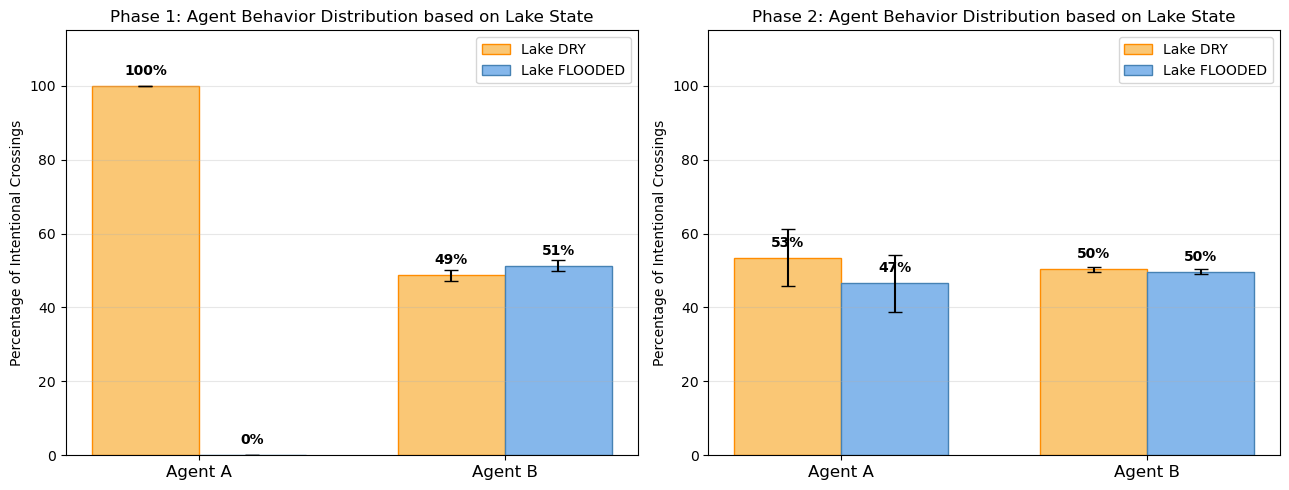

In [7]:
def plot_lake_crossing_with_errorbars(metrics_p1, metrics_p2):
    # 1. Initialize the main figure layout
    # Create a figure with 1 row and 2 columns of subplots, setting the overall size to 13x5 inches.
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    width = 0.35       
    x = np.arange(2)   # Set base x-axis positions: 0 corresponds to Agent A, 1 to Agent B
    
    # 2. Iterate through both evaluation phases to generate subplots sequentially
    for idx, (metrics, phase_name, ax) in enumerate([
        (metrics_p1, 'Phase 1', axes[0]),
        (metrics_p2, 'Phase 2', axes[1])
    ]):
        # Extract evaluation data and calculate the statistical mean and standard deviation (error bars) across the 5 seeds
        a_dry_mean = np.mean(metrics['A_dry_pct']); a_dry_std = np.std(metrics['A_dry_pct'])
        a_flo_mean = np.mean(metrics['A_flooded_pct']); a_flo_std = np.std(metrics['A_flooded_pct'])
        b_dry_mean = np.mean(metrics['B_dry_pct']); b_dry_std = np.std(metrics['B_dry_pct'])
        b_flo_mean = np.mean(metrics['B_flooded_pct']); b_flo_std = np.std(metrics['B_flooded_pct'])
        
        # [Plotting]: Render the bars representing 'Lake DRY' crossings (Light Orange)
        # Offset the bars to the left (x - width/2) to accommodate the grouped layout
        bars1 = ax.bar(x - width/2, [a_dry_mean, b_dry_mean], width, 
                       yerr=[a_dry_std, b_dry_std], capsize=5,
                       label='Lake DRY', color='#FAC775', edgecolor='darkorange')
                       
        # [Plotting]: Render the bars representing 'Lake FLOODED' crossings (Light Blue)
        bars2 = ax.bar(x + width/2, [a_flo_mean, b_flo_mean], width,
                       yerr=[a_flo_std, b_flo_std], capsize=5,
                       label='Lake FLOODED', color='#85B7EB', edgecolor='steelblue')
        
        # 3. Annotate bars with precise numerical percentage values
        for bars in [bars1, bars2]:
            for bar in bars:
                h = bar.get_height()  # Retrieve the computed height of the current bar
                # Position the text annotation centrally above the bar, shifted upwards by 3 points
                # Format to display as an integer percentage with no decimal places (e.g., "100%")
                ax.text(bar.get_x() + bar.get_width()/2, h + 3, f'{h:.0f}%',
                        ha='center', fontsize=10, fontweight='bold')
        
        # 4. Format subplot aesthetics and coordinate axes
        ax.set_xticks(x)                                         # Define tick locations on the x-axis
        ax.set_xticklabels(['Agent A', 'Agent B'], fontsize=12)  # Assign categorical labels to the x-axis
        ax.set_ylabel('Percentage of Intentional Crossings')     # Set y-axis label to reflect behavioral intent              
        ax.set_title(f'{phase_name}: Agent Behavior Distribution based on Lake State') # Apply descriptive subplot title
        ax.legend()                                              # Display legend to differentiate lake states
        ax.set_ylim(0, 115)                                      # Extend y-axis maximum to 115 to accommodate annotations and error bars
        ax.grid(axis='y', alpha=0.3)                             # Add faint horizontal gridlines to assist with visual alignment
    
    plt.tight_layout()  # Automatically adjust subplots to prevent overlapping elements
    plt.show()          

plot_lake_crossing_with_errorbars(metrics_p1, metrics_p2)

## Task 3. Evolutionary Game Theory Analysis: Replicator Dynamics

### 1. Theoretical Framework
To rigorously formally understand the equilibrium selection observed during the Q-learning evaluation, we transition from empirical analysis to a theoretical framework using **Evolutionary Game Theory (EGT)**. Specifically, we employ **Replicator Dynamics** to model how the probability distribution of strategies evolves over time based on their relative expected payoffs.

Let $x \in [0, 1]$ represent the probability (or population proportion) of Agent A selecting Strategy 1 ("Cross when DRY"), and $y \in [0, 1]$ represent the corresponding probability for Agent B. The core premise of this dynamic is natural selection: strategies that yield a higher payoff than the population's average will see an increased probability of selection, while underperforming strategies will gradually face extinction.

### 2. Mathematical Formulation
For a defined payoff matrix, the expected payoff for Agent A choosing Strategy 1 ($f_{A1}$) and Strategy 2 ($f_{A2}$) is strictly dependent on the current strategy distribution $y$ of Agent B. Consequently, the average expected payoff for the entire Agent A population ($\bar{f}_A$) is formulated as:

$$ \bar{f}_A = x \cdot f_{A1} + (1 - x) \cdot f_{A2} $$

The continuous-time evolution of these strategy proportions is governed by the following system of non-linear differential equations:

$$ \frac{dx}{dt} = x (f_{A1} - \bar{f}_A) $$
$$ \frac{dy}{dt} = y (f_{B1} - \bar{f}_B) $$

Where $\frac{dx}{dt}$ and $\frac{dy}{dt}$ represent the rate of change in the probability of selecting Strategy 1 for Agent A and Agent B, respectively. To simulate this continuous process computationally, we utilize the **Euler Method**, scaling the rate of change by a discrete time step ($dt$) to update the probabilities iteratively: $x_{t+1} = x_t + \frac{dx}{dt} \cdot dt$.

### 3. Phase Portrait Visualization
In the following implementation, we numerically solve these differential equations to plot the **Phase Portraits** for both experimental phases. By initializing the system from various starting coordinates $(x_0, y_0)$, we can trace the evolutionary trajectories to identify:
* **Phase 1 (Asymmetric Coordination):** How the severe water penalty uniquely drives the system toward a single, stable Nash Equilibrium.
* **Phase 2 (Symmetric Anti-Coordination):** The emergence of multistability (two stable pure-strategy equilibria and one unstable mixed-strategy equilibrium) in the absence of environmental symmetry-breaking mechanisms.

### 4. Analytical Proof of the Interior Mixed-Strategy Equilibrium
To rigorously validate the phase portrait trajectory observed in Phase 2, we can analytically calculate the exact coordinate of the unstable interior saddle point. In a mixed-strategy Nash Equilibrium, a player must be completely indifferent between their available pure strategies, meaning the expected payoffs of both strategies must be perfectly equal.

Let $y$ represent the probability that Agent B chooses the "Cross when DRY" strategy. Given the symmetric payoff matrix in Phase 2, we can formulate Agent A's expected payoffs for each strategy:

**1. Expected payoff for Agent A choosing DRY:**
$$ E_A(\text{DRY}) = y \cdot (-20) + (1 - y) \cdot 0 = -20y $$

**2. Expected payoff for Agent A choosing FLOODED:**
$$ E_A(\text{FLOODED}) = y \cdot 0 + (1 - y) \cdot (-20) = -20 + 20y $$

**3. Equating the expected payoffs to find the indifference point:**
By setting $E_A(\text{DRY}) = E_A(\text{FLOODED})$, we find the specific probability distribution where Agent A has no incentive to deviate:

$$ -20y = -20 + 20y $$
$$ 40y = 20 $$
$$ y = 0.5 $$

Due to the symmetry of the game, the exact same logic applies to Agent A's probability ($x = 0.5$). Thus, we mathematically prove that the unstable saddle point is located precisely at $(0.5, 0.5)$, which flawlessly corroborates the visual watershed divergence observed in our plotted replicator dynamics phase portrait.


In [8]:
def replicator_dynamics(payoff_A, payoff_B, prop_a_dry, prop_b_dry, dt=0.01, total_time=200, label=""):
    """
    Simulate 2x2 two-population Replicator Dynamics.
    
    Parameters:
    payoff_A: Payoff matrix for Agent A.
    payoff_B: Payoff matrix for Agent B.
    prop_a_dry: Initial probability/proportion of Agent A choosing Strategy 1 (e.g., cross when DRY). Default is 0.5 (evenly split).
    prop_b_dry: Initial probability/proportion of Agent B choosing Strategy 1 (e.g., cross when DRY). Default is 0.5 (evenly split).
    dt: Time step (Delta Time). The interval for each computational update; smaller values yield higher precision. Default is 0.01.
    total_time: Total duration of the simulation. Defaults to 100 periods.
    """
    n_steps = int(total_time / dt)  
    
    # Record the evolutionary history of proportions over time
    history_A_strat = np.zeros(n_steps)
    history_B_strat = np.zeros(n_steps)
    
    # Set the initial proportions for Day 0
    history_A_strat[0] = prop_a_dry
    history_B_strat[0] = prop_b_dry
    
    for time in range(n_steps - 1):
        prop_A = history_A_strat[time]
        prop_B = history_B_strat[time]
        
        # ==========================================
        # Step 1: Calculate the Expected Payoff for individual strategies
        # ==========================================
        exp_payoff_A_strat1 = prop_B * payoff_A[0,0] + (1 - prop_B) * payoff_A[0,1]    # Agent A choosing Dry
        exp_payoff_A_strat2 = prop_B * payoff_A[1,0] + (1 - prop_B) * payoff_A[1,1]    # Agent A choosing Flooded
        
        exp_payoff_B_strat1 = prop_A * payoff_B[0,0] + (1 - prop_A) * payoff_B[1,0]    # Agent B choosing Dry
        exp_payoff_B_strat2 = prop_A * payoff_B[0,1] + (1 - prop_A) * payoff_B[1,1]    # Agent B choosing Flooded
        
        # ==========================================
        # Step 2: Calculate the Average Population Payoff
        # ==========================================
        avg_payoff_A = prop_A * exp_payoff_A_strat1 + (1 - prop_A) * exp_payoff_A_strat2    # Average payoff for Agent A 
        avg_payoff_B = prop_B * exp_payoff_B_strat1 + (1 - prop_B) * exp_payoff_B_strat2    # Average payoff for Agent B 
        
        # ==========================================
        # Step 3: Core Replicator Dynamics Equations
        # ==========================================
        change_rate_A = prop_A * (exp_payoff_A_strat1 - avg_payoff_A)
        change_rate_B = prop_B * (exp_payoff_B_strat1 - avg_payoff_B)
        
        # ==========================================
        # Step 4: Update proportions for the next time step (Euler Method)
        # ==========================================
        history_A_strat[time+1] = prop_A + change_rate_A * dt
        history_B_strat[time+1] = prop_B + change_rate_B * dt
    
    return history_A_strat, history_B_strat

# ===== Phase 1 Payoff Matrices (Asymmetric Coordination Game) =====
# Agent A is vulnerable to water in Phase 1 (incurs an extra -20 penalty if flooded).
P_A_phase1 = np.array([
    #   B Dry       B Flooded
    [   -20,            0    ],  # A Dry
    [   -20,          -40    ]   # A Flooded (Water penalty applied; -40 if also collision)
])

P_B_phase1 = np.array([
    #   B Dry       B Flooded
    [   -20,            0    ],  # A Dry
    [     0,          -20    ]   # A Flooded
    # Note: Agent B is waterproof. Penalties only occur from collisions.
])


# ===== Phase 2 Payoff Matrices (Symmetric Anti-Coordination Game) =====
P_A_phase2 = np.array([
    #   B Dry       B Flooded
    [   -20,            0    ],  # A Dry
    [     0,          -20    ]   # A Flooded
])

P_B_phase2 = np.array([
    #   B Dry       B Flooded
    [   -20,            0    ],  # A Dry
    [     0,          -20    ]   # A Flooded
])

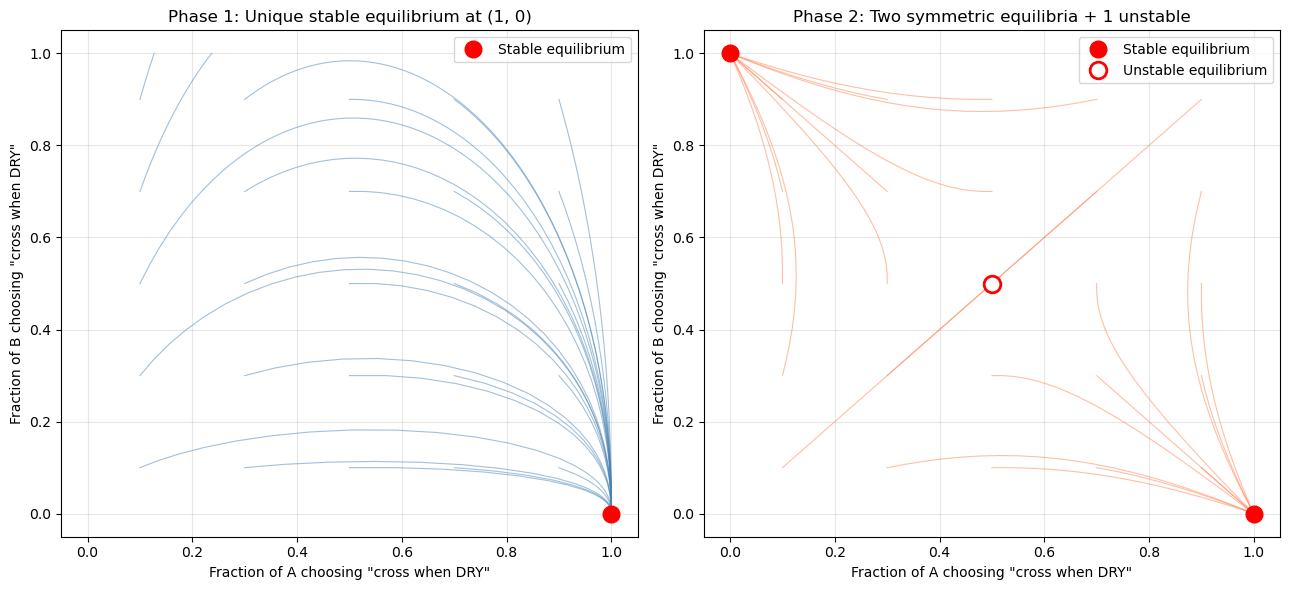

In [9]:
# ===== Visualization: Plotting Phase Portraits =====
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ---- Phase 1 Trajectories ----
ax = axes[0] 
# Generate a 5x5 grid of 25 different initial probability combinations (starting points)
for init_A in np.linspace(0.1, 0.9, 5):
    for init_B in np.linspace(0.1, 0.9, 5):
        # Run the replicator dynamics model to calculate trajectory points over 200 time steps
        hist_A, hist_B = replicator_dynamics(P_A_phase1, P_B_phase1, prop_a_dry=init_A, prop_b_dry=init_B, total_time=200)
        ax.plot(hist_A, hist_B, alpha=0.5, color='steelblue', linewidth=0.8)

# Plot a solid red circle at (1, 0) to represent the stable equilibrium
ax.plot(1, 0, 'ro', markersize=12, zorder=10, label='Stable equilibrium')
ax.legend(loc='upper right') # Display legend in the upper right corner
ax.set_xlabel('Fraction of A choosing "cross when DRY"') # X-axis label
ax.set_ylabel('Fraction of B choosing "cross when DRY"') # Y-axis label
ax.set_title('Phase 1: Unique stable equilibrium at (1, 0)') # Title
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05) # Slightly widen the axes limits to prevent edge clipping
ax.grid(alpha=0.3) # Add a subtle background grid

# ---- Phase 2 Trajectories ----
ax = axes[1] 
# Similarly, generate 25 starting points to run the loop
for init_A in np.linspace(0.1, 0.9, 5):
    for init_B in np.linspace(0.1, 0.9, 5):
        hist_A, hist_B = replicator_dynamics(P_A_phase2, P_B_phase2, prop_a_dry=init_A, prop_b_dry=init_B, total_time=200)
        ax.plot(hist_A, hist_B, alpha=0.5, color='coral', linewidth=0.8)

# Phase 2 has two stable equilibria at (0, 1) and (1, 0); plot them as solid red dots
ax.plot(0, 1, 'ro', markersize=12, zorder=10, label='Stable equilibrium')
ax.plot(1, 0, 'ro', markersize=12, zorder=10)

# The center point (0.5, 0.5) is a saddle-like unstable equilibrium; plot it as a hollow circle with a red edge
ax.plot(0.5, 0.5, 'o', markersize=12, markerfacecolor='white', 
        markeredgecolor='red', markeredgewidth=2, zorder=10, 
        label='Unstable equilibrium')
        
ax.legend(loc='upper right')
ax.set_xlabel('Fraction of A choosing "cross when DRY"')
ax.set_ylabel('Fraction of B choosing "cross when DRY"')
ax.set_title('Phase 2: Two symmetric equilibria + 1 unstable')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout() 
plt.show()

In the phase portraits, each point $(x, y)$ represents a **joint strategy profile**, where $x$ denotes the proportion of Agent A's population choosing the "Cross when DRY" strategy, and $y$ denotes the corresponding proportion for Agent B.

**Phase 1:** The replicator dynamics consistently converge to a unique stable equilibrium at $(1, 0)$. This mathematical convergence precisely corresponds to a coordination strategy where Agent A exclusively crosses during DRY conditions, and Agent B exclusively crosses during FLOODED conditions. This fundamentally validates Sarah's prediction in the assignment scenario: the water vulnerability naturally functions as a **"natural traffic light,"** effortlessly resolving the coordination problem without requiring explicit communication.

**Phase 2:** This scenario fundamentally shifts to an **anti-coordination game**, characterized by the coexistence of two stable pure-strategy Nash equilibria: $(1, 0)$ and $(0, 1)$. The system's ultimate convergence location is strictly dictated by the initial probability distribution. This phenomenon, known in evolutionary game theory as **multistability** or **path dependence**, demonstrates that without the natural asymmetry (the water penalty), the final societal outcome is highly contingent on historical starting points.

## Task 4: RL Simulation vs. Theoretical EGT Equilibria

The divergence between theoretical EGT and empirical independent Q-learning stems from the critical difference between deterministic assumptions and stochastic environments.

In Phase 1, EGT assumes guaranteed collisions for joint "DRY" actions, yielding perfect coordination. Conversely, RL operates via Expected Value. Because simultaneous arrivals are rare, low-probability events, the mathematical expectation of the collision penalty is heavily diluted compared to the massive task completion reward. Consequently, Agent B calculates that crossing during DRY remains highly profitable. It makes a rational choice under uncertainty, ultimately settling into a suboptimal but stable local optimum.

In Phase 2, removing the water penalty creates a perfectly symmetric game. While EGT mathematically resolves this via population-level evolutionary dynamics, independent RL agents lack any external symmetry-breaking mechanism. Without explicit communication, they cannot successfully coordinate who yields, inevitably suffering from the classic Equilibrium Selection Problem and remaining permanently deadlocked near the 50/50 unstable state.